In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import lightkurve as lk
import numpy as np
from scipy.optimize import least_squares
from scipy import optimize
from astropy import units as u
from astropy import constants as const
from astroquery.mast import Catalogs
import batman
import radvel
from dace_query.spectroscopy import Spectroscopy
import pandas as pd

2026-09-04 19:32:49,268 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [2]:
render_plots = True

In [3]:
input_catalog = input('input catalog: ').upper()
split = input_catalog.split(' ')
telescope = split[0]
if telescope == 'TIC':
    author = 'SPOC'
if telescope == 'KIC':
    author = 'Kepler'

filepath = '/Users/joshu/Code/NasaExoplanetArchive_2026.08.23_12.42.57.csv' 
nasa_archive = pd.read_csv(filepath, comment = '#')
nasa_exo = nasa_archive[nasa_archive['tic_id'] == input_catalog]
print(f'Parent Star: {nasa_exo.iloc[0]['hostname']}')
print(f'Distance: {np.round(nasa_exo.iloc[0]['sy_dist']*u.parsec.to(u.lightyear), 2)} ly')

try:
    star = Catalogs.query_object(input_catalog, catalog = 'TIC') 
    star_Teff = star['Teff'][0]
    star_lumclass = str(star['lumclass'][0]).capitalize()
    if star_Teff >= 33000:
        stellar_class = str(f'O-Type Blue {star_lumclass}')
    elif star_Teff >= 10000:
        stellar_class = str(f'B-Type Blue/White {star_lumclass}')
    elif star_Teff >= 7300:
        stellar_class = str(f'A-Type White {star_lumclass}')
    elif star_Teff >= 6000:
        stellar_class = str(f'F-Type White/Yellow {star_lumclass}')
    elif star_Teff >= 5300:
        stellar_class = str(f'G-Type Yellow {star_lumclass}')
    elif star_Teff >= 3900:
        stellar_class = str(f'K-Type Orange {star_lumclass}')
    elif star_Teff >= 2300:
        stellar_class = str(f'M-Type Red {star_lumclass}')
    else:
        stellar_class = 'Brown Dwarf'  
    print(f'Stellar Class: {stellar_class}')
except:
    print('MAST import error: try again')

RV = False
if nasa_exo['rv_flag'].any() == 1:
    RV = True
print(f'Radial Velocity Available: {RV}')

input catalog:  tic 266980320


Parent Star: HD 219666
Distance: 307.15 ly
Stellar Class: G-Type Yellow Dwarf
Radial Velocity Available: True


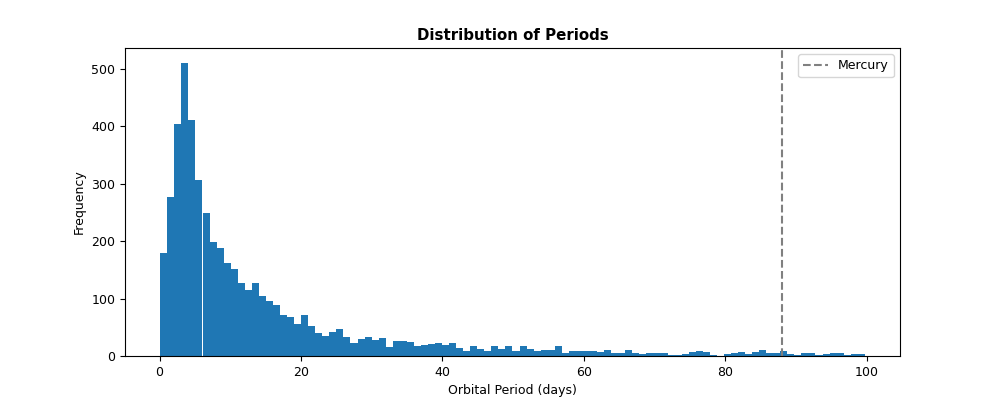

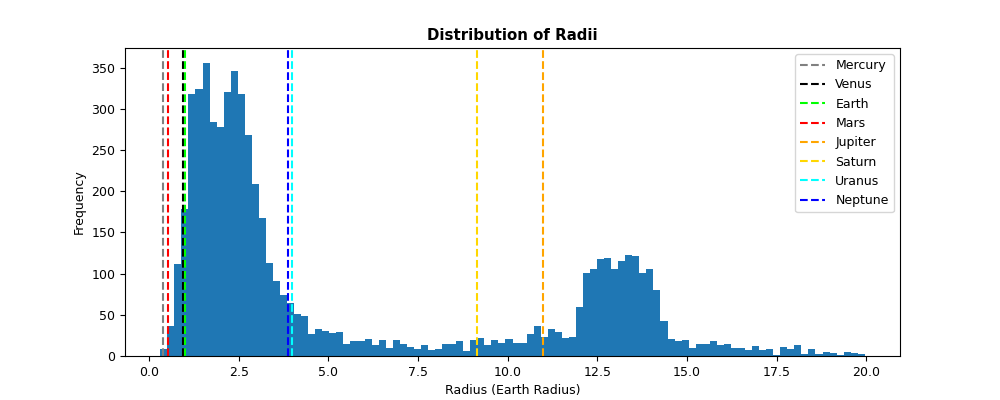

In [100]:
def plot_distributions():
    plt.figure(figsize = (10,4))
    nasa_archive.loc[nasa_archive['pl_orbper'] < 100, 'pl_orbper'].plot.hist(bins = 100, label = '_nolegend_')
    plt.title('Distribution of Periods', fontweight = 'bold')
    plt.xlabel('Orbital Period (days)')
    plt.axvline(87.969, color = 'grey', linestyle = '--', label = 'Mercury')
    plt.legend()
    plt.show()
    
    plt.figure(figsize = (10,4))
    nasa_archive.loc[nasa_archive['pl_rade'] < 20, 'pl_rade'].plot.hist(bins = 100, label = '_nolegend_')
    plt.title('Distribution of Radii', fontweight = 'bold')
    plt.xlabel('Radius (Earth Radius)')
    plt.axvline(0.383, color = 'grey', linestyle = '--', label = 'Mercury')
    plt.axvline(0.95, color = 'black', linestyle = '--', label = 'Venus')
    plt.axvline(1, color = 'lime', linestyle = '--', label = 'Earth')
    plt.axvline(0.53, color = 'red', linestyle = '--', label = 'Mars')
    plt.axvline(10.97, color = 'orange', linestyle = '--', label = 'Jupiter')
    plt.axvline(9.14, color = 'gold', linestyle = '--', label = 'Saturn')
    plt.axvline(3.98, color = 'cyan', linestyle = '--', label = 'Uranus')
    plt.axvline(3.86, color = 'blue', linestyle = '--', label = 'Neptune')
    plt.legend()
    plt.show()

plot_distributions()

### Transit Method

In [5]:
automate_data_cell = True

In [6]:
def import_tess(input_catalog, author, all_data, years):    
    sectors_list = []
    for sector in all_data.table:
        sectors_list.append(int(sector['sequence_number']))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:           
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        
    print('\nselected data:')
    print(selected_data)        
    return raw_ts, sectors_list, selected_data

def import_kepler(input_catalog, author, all_data, years):    
    quarters_list = []
    for quarter in all_data.table:
        quarters_list.append(int(quarter['mission'].split(' ')[2]))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:            
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()

        
    print('\nselected data:')
    print(selected_data)
    return raw_ts, quarters_list, selected_data

def limit_range(all_data):
    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table['year'] >= yr_mode - 2) & (all_data.table['year'] <= yr_mode + 2)
        else:
            year_mask = (all_data.table['year'] >= yr_median - 2) & (all_data.table['year'] <= yr_median + 2)
    else:
        year_mask = all_years
    return yr_range, year_mask

all_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short')
print('all data:')
print(all_data)

if automate_data_cell == True:
    years = 0
    automate_data_cell = False
else:
    years_input = input('Year Range: ')
    years_range = years_input.split('-')
    years_min = int(years_range[0])
    years_max = int(years_range[-1])
    if years_min != years_max:
        years = [years_min]
        i = 1
        while years[-1] != years_max:
            years.append(years_min + i)
            i += 1
    
if telescope == 'TIC':
    raw_ts, sectors, selected_data = import_tess(input_catalog, author, all_data, years)
if telescope == 'KIC':
    raw_ts, quarters, selected_data = import_kepler(input_catalog, author, all_data, years)

all data:
SearchResult containing 8 data products.

 #      mission     year author exptime target_name distance
                                   s                 arcsec 
--- --------------- ---- ------ ------- ----------- --------
  0  TESS Sector 01 2018   SPOC     120   266980320      0.0
  1  TESS Sector 28 2020   SPOC     120   266980320      0.0
  2  TESS Sector 68 2023   SPOC     120   266980320      0.0
  3  TESS Sector 95 2025   SPOC     120   266980320      0.0
  4 TESS Sector 102 2026   SPOC     120   266980320      0.0
  5 TESS Sector 103 2026   SPOC     120   266980320      0.0
  6 TESS Sector 104 2026   SPOC     120   266980320      0.0
  7 TESS Sector 105 2026   SPOC     120   266980320      0.0

selected data:
SearchResult containing 5 data products.

 #      mission     year author exptime target_name distance
                                   s                 arcsec 
--- --------------- ---- ------ ------- ----------- --------
  0  TESS Sector 95 2025   SPOC     

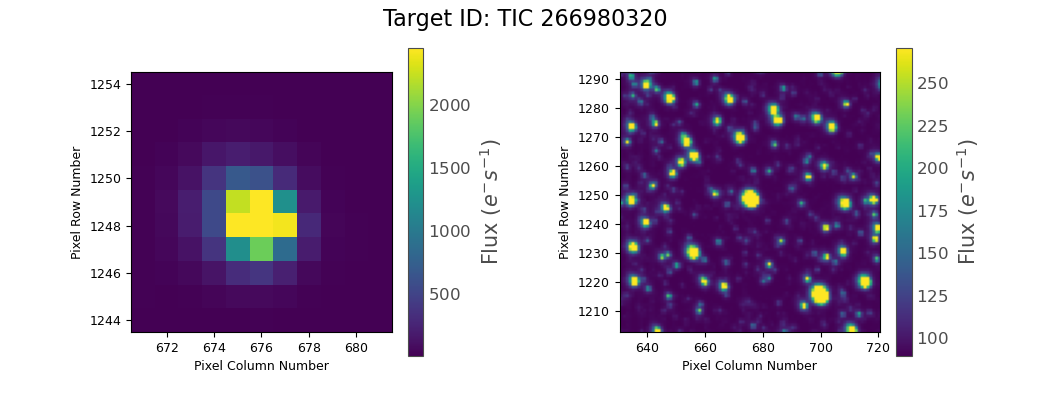

In [7]:
if render_plots == True:
    if telescope == 'TIC':
        fig, (ax1, ax2) = plt.subplots(nrows = 1 ,ncols = 2, figsize = (10.5, 4))
        fig.suptitle(f'Target ID: {input_catalog}', fontsize = 16)
        fig.subplots_adjust(wspace = .5)
        
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', sector = sectors[0]).download()
        px_file.plot(ax = ax1, title = '')
        
        ff_file = lk.search_tesscut(input_catalog, sector = sectors[0]).download(cutout_size = 90)
        ff_file.plot(ax = ax2, title = '')
        
    if telescope == 'KIC':
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', quarter = quarters[0]).download()
        px_file.plot()
        plt.title(f'Target ID: {input_catalog}', fontsize = 16)

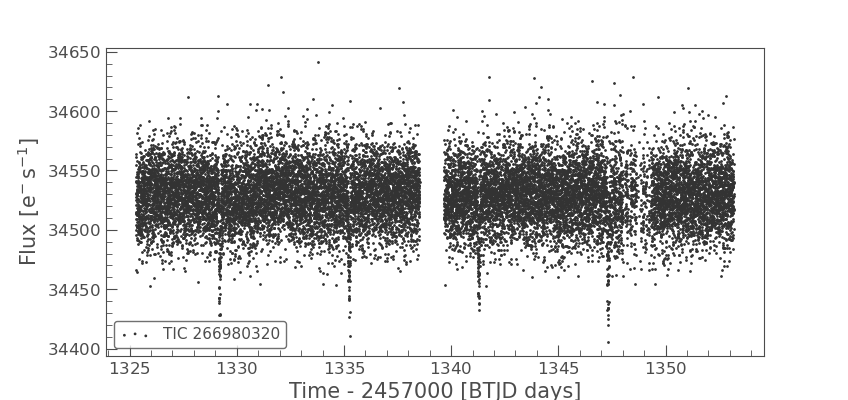

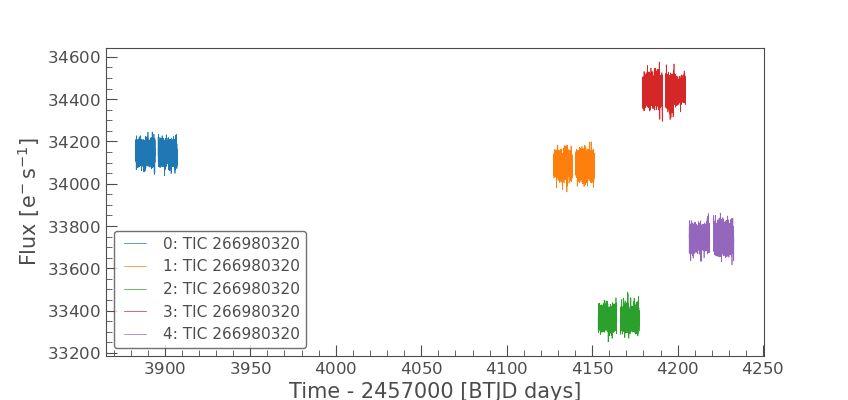

In [8]:
if telescope == 'TIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors[0], limit = 1).download()
    if len(sectors) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if telescope == 'KIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters[0], limit = 1).download()
    if len(quarters) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if render_plots == True:
    first_ts.scatter()
    raw_ts.plot()

In [9]:
bin_count = 100000
if len(refined_ts) > bin_count:
    bin_width = (np.max(refined_ts.time.value)-np.min(refined_ts.time.value))/(bin_count/.94)
    harmonics_ts = refined_ts.bin(bin_width) 
else:
    harmonics_ts = refined_ts
print(f'Count of points in harmonics test: {len(harmonics_ts)}')

Count of points in harmonics test: 76693


In [10]:
add_period = False

Exoplanet Index: 0
Period: 6.0346 d (SNR: 20.273)



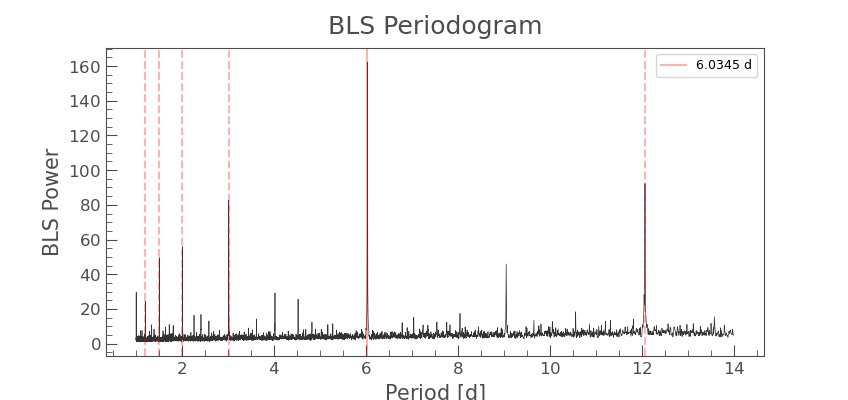

In [11]:
def initial_bls(ts, min_period, max_period):
    search_duration = np.linspace(.05, .3, 10)
    search_period = np.logspace(np.log10(min_period), np.log10(max_period), 5000) 
    initial_periodogram = ts.to_periodogram(method = 'bls', period = search_period, duration = search_duration, frequency_factor = 1000)
    initial_period = initial_periodogram.period_at_max_power
    initial_duration = initial_periodogram.duration_at_max_power  
    return initial_periodogram, initial_period, initial_duration
    
def refine_bls(ts, prev_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(prev_period.value - .1, prev_period.value + .1, 5000)
    refined_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    refined_period = refined_periodogram.period_at_max_power
    refined_duration = refined_periodogram.duration_at_max_power
    refined_time = refined_periodogram.transit_time_at_max_power
    refined_depth = refined_periodogram.depth_at_max_power
    return refined_periodogram, refined_period, refined_duration, refined_time, refined_depth

def search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts):
    harmonics = [refined_period.value]
    i = 2
    while i <= 5:
        harmonics_divide = refined_period.value/i
        harmonics_multiply = refined_period.value*i
        if harmonics_divide >= min_period:
            harmonics.append(harmonics_divide)
        if harmonics_multiply <= max_period:
            harmonics.append(harmonics_multiply)
        i += 1 
    harmonics.sort()
    
    dip_ratio = []
    for each in harmonics:
        folded = harmonics_ts.fold(period = each, epoch_time = refined_time)
        in_transit = np.logical_and((folded.phase.value > -refined_duration.value/3), (folded.phase.value < refined_duration.value/3))
        above_dip = folded.flux.value > 1-refined_depth*(2/3)
        both = np.logical_and(in_transit, above_dip)
        dip_ratio.append(len(folded[both])/len(folded[in_transit]))

        #lim_folded = folded[in_transit]
        #folded.scatter(title = f'index {harmonics.index(each)}: {round(each*u.day,4)}')
        #plt.axhline(1-refined_periodogram.depth_at_max_power*(2/3), color = "green")
        #plt.axvline(-refined_duration.value/3, color = "green")
        #plt.axvline(refined_duration.value/3, color = "green")
        #plt.xlim(-.1,.1)
        #plt.ylim(.9995, 1.0005)
    
    high_freq_h = []
    mean = (dip_ratio[0]+dip_ratio[-1])/2
    
    i = 0
    while i < len(dip_ratio):
        if dip_ratio[i] > mean:
            high_freq_h.append(dip_ratio[i])
        i += 1
    
    transit_index = len(high_freq_h)
    return harmonics, transit_index

def mask_ts(time_series, ts, selected_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(selected_period - .1, selected_period + .1, 5000)
    final_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    final_period = final_periodogram.period_at_max_power
    final_duration = final_periodogram.duration_at_max_power
    final_time = final_periodogram.transit_time_at_max_power
    final_depth = final_periodogram.depth_at_max_power
    
    mask = final_periodogram.get_transit_mask(period = final_period, transit_time = final_time, duration = final_duration*2)
    masked_ts = ts[~mask]
    time_series.append(masked_ts)
    return final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth

def plot_periodogram(periodogram, selected_periods, min_period, max_period):
    periodogram.plot(title = 'BLS Periodogram', label = '_nolegend_')
    
    i = 0
    while i < len(selected_periods):
        if i == 0:
            color = 'red'
        if i == 1:
            color = 'green'
        if i == 2:
            color = 'blue'
        if i == 3:
            color = 'orange'
        if i == 4:
            color = 'purple'
        plt.axvline(selected_periods[i], color = color, alpha = .3)

        labels = []
        for each in selected_periods:
            labels.append(round(each,4)*u.day)
        plt.legend(labels)
        
        x = 2
        while x <= 5:
            harmonics_divide = selected_periods[i]/x
            harmonics_multiply = selected_periods[i]*x
            if harmonics_divide >= min_period:
                plt.axvline(harmonics_divide, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            if harmonics_multiply <= max_period:
                plt.axvline(harmonics_multiply, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            x += 1 
        i += 1

if add_period == False:
    min_period = 1
    max_period = 14
    time_series = [refined_ts]
    cycle = 0
    selected_periods = []
    exoplanets = []
    periods = []
    durations = []
    transit_times = []
    
    while True:
        initial_periodogram, initial_period, initial_duration = initial_bls(time_series[-1], min_period, max_period)
        if cycle == 0:
            first_periodogram = initial_periodogram
        cycle += 1
    
        refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
        if np.max(refined_periodogram.snr) < 10:
            break

        harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
        for each in harmonics:
            if each == harmonics[transit_index]:
                selected_periods.append(each)
        
        final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
        exoplanets.append({
            'stellar_class': stellar_class,
            'period': final_period, 
            'duration': final_duration, 
            'transit_t0': final_time,       
            'depth': final_depth,
            'snr': np.max(final_periodogram.snr)
        }) 
        periods.append(final_period.value)
        durations.append(final_duration.value)
        transit_times.append(final_time.value)
    add_period = True
else:
    refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
    harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
    for each in harmonics:
        if each == harmonics[transit_index]:
            selected_periods.append(each)
    final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
    exoplanets.append({
        'stellar_class': stellar_class,
        'period': final_period, 
        'duration': final_duration, 
        'transit_t0': final_time,       
        'depth': final_depth,
        'snr': np.max(final_periodogram.snr)
    }) 
    periods.append(final_period.value)
    durations.append(final_duration.value)
    transit_times.append(final_time.value)  

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    print(f'Period: {round(each["period"],4)} (SNR: {round(each["snr"],4)})')
    print()
plot_periodogram(first_periodogram, selected_periods, min_period, max_period)

In [12]:
def orbital_distance(star, period):
    star_mass = star['mass'][0]* u.M_sun
    star_mass = star_mass.to(u.kg)
    period = period.to(u.s)
    sm_axis = np.cbrt((const.G*star_mass*np.square(period))/(4*np.square(np.pi)))
    sm_axis = sm_axis.to(u.au)
    print(f'Semimajor Axis: {round(sm_axis, 4)}') 
    return sm_axis

def equ_temperature(star, sm_axis):
    star_rad = star['rad'][0]*u.Rsun.to(u.m)*u.m
    star_temp = star_Teff*u.k
    sm_axis_m = sm_axis.to(u.m)
    equ_temp = star_temp * ((star_rad/(2*sm_axis_m))**(1/2)) * (1**(1/4))
    print(f'Equilibrium Temperature: {round(equ_temp, 4)}')
    return equ_temp

def habitable_zone(star, sm_axis):
    star_luminosity = star['lum'][0]*u.L_sun
    inner_lim = np.sqrt(star_luminosity/(1.1*u.L_sun))*u.au
    outer_lim = np.sqrt(star_luminosity/(.53*u.L_sun))*u.au

    if sm_axis < inner_lim:
        habitability = 'too hot'
    elif sm_axis > outer_lim:
        habitability = 'too cold'
    else:
        habitability = 'just right'
    print(f'Habitability: {habitability}')
    return habitability

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    sm_axis = orbital_distance(star, each['period'])
    each['sm_axis'] = sm_axis

    equ_temp = equ_temperature(star, each['sm_axis'])
    each['equ_temp'] = equ_temp

    habitability = habitable_zone(star, each['sm_axis'])
    each['habitability'] = habitability
    print()

Exoplanet Index: 0
Semimajor Axis: 0.0642 AU
Equilibrium Temperature: 1078.5824 k
Habitability: too hot



In [15]:
remove_lc = False

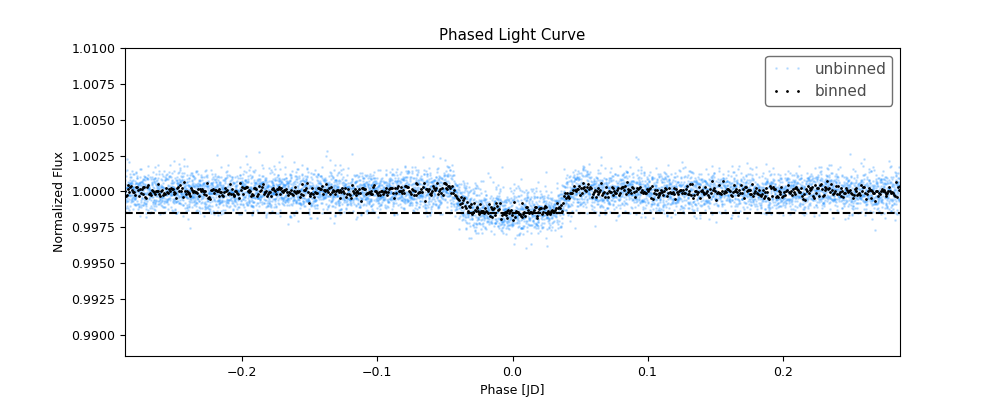

Exoplanet Index: 0
4.3972 earthRad
0.3923 jupiterRad


In [16]:
def clean_data(mission, refined_ts):
    transit_mask = refined_ts.create_transit_mask(
                period = periods, 
                transit_time = transit_times, 
                duration = durations
            )
    if len(mission) > 1:
        clean_ts = raw_ts.stitch().remove_nans().flatten(mask = transit_mask)
    else:
        clean_ts = first_ts.remove_nans().flatten(mask = transit_mask)
    return clean_ts

def plot_light_curve(clean_ts, period, t0, duration):
    phased_lc = clean_ts.fold(period = period, epoch_time = t0)
    binned_lc = phased_lc.bin(1/60/24)
    dip = np.mean(binned_lc[np.logical_and(binned_lc.time > -duration*.1, binned_lc.time < duration*.1)].flux.value)
    depth = 1-dip
    half_duration = duration.value/2
    if render_plots == True:
        fig, ax = plt.subplots(figsize = (10,4))
        phased_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "dodgerblue", alpha = .2, label = "unbinned")
        binned_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "black", label = "binned")
        plt.axhline(dip, color = 'black', linestyle = '--')
        plt.title("Phased Light Curve")
        plt.xlim(-(half_duration + .25), (half_duration + .25))
        plt.ylim(dip - .01, 1.01)
        plt.show()
    return depth, binned_lc, phased_lc

def estimate_radius(star, depth):
    exo_sun_rad = np.sqrt(depth) * (star["rad"][0] * u.R_sun)
    exo_earth_rad = exo_sun_rad.to(u.Rearth) 
    exo_jupiter_rad = exo_sun_rad.to(u.Rjupiter) 
    print(round(exo_earth_rad, 4))
    print(round(exo_jupiter_rad, 4))
    return exo_earth_rad

def run_lc_loop(exoplanets, clean_ts):
    for each in exoplanets:
        depth, binned_lc, phased_lc = plot_light_curve(clean_ts, each["period"], each["transit_t0"], each["duration"])
        each["depth"] = depth*1000*u.mmag
    
        transit_event = np.logical_and(binned_lc.phase.value > -0.2, binned_lc.phase.value < 0.2)
        each["light_curve"] = binned_lc[transit_event]

        print(f'Exoplanet Index: {exoplanets.index(each)}')
        radius = estimate_radius(star, depth)
        each["radius"] = radius

if remove_lc == False:
    if telescope == "TIC":
        clean_ts = clean_data(sectors, refined_ts)
    if telescope == "KIC":
        clean_ts = clean_data(quarters, refined_ts)
        
    run_lc_loop(exoplanets, clean_ts)
    remove_lc = True
else:
    remove_index = int(input('Remove Candidate(s)?'))
    del exoplanets[remove_index]
    run_lc_loop(exoplanets, clean_ts)

Exoplanet Index: 0
Radius: 4.4225 earthRad
Inclination: 86.3059 deg
Eccentricity: 0.0272
Argument of Periapsis (ω): 0.0 deg


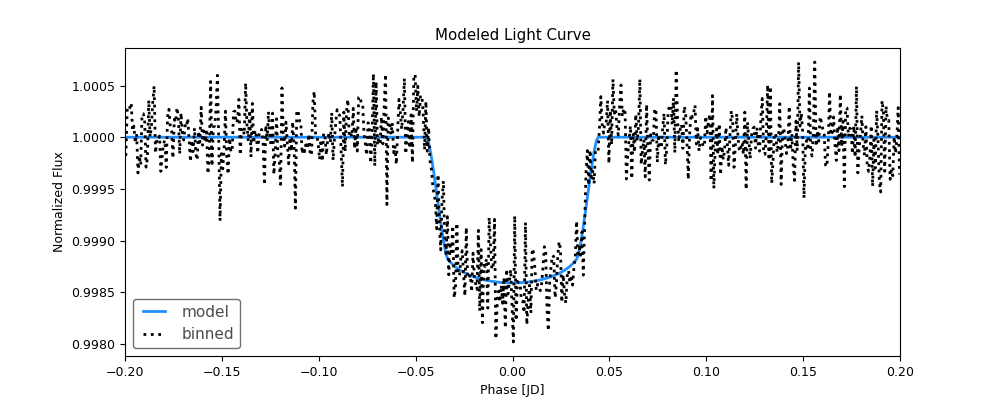

In [17]:
def initial_estimates(exoplanet, star):
    rad_est = (exoplanet['radius'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    inc_est = 90
    ecc_est = 0
    w_est = 90
    estimates = [rad_est, inc_est, ecc_est, w_est]
    lower_bounds = [rad_est-0.02,80,0,0]
    upper_bounds = [rad_est+0.02,90,0.999,180]
    return estimates, lower_bounds, upper_bounds
    
def batman_fun(x, exoplanet, star):
    params = batman.TransitParams()
    params.t0 = 0
    params.per = exoplanet['period'].value
    params.rp = x[0]
    params.a = (exoplanet['sm_axis'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    params.inc = x[1]
    params.ecc = x[2]
    params.w = x[3]
    params.limb_dark = 'nonlinear'
    params.u = [0.5,0.1,0.1,-0.1]  
    
    phase_min = min(exoplanet['light_curve'].phase.value)
    phase_max = max(exoplanet['light_curve'].phase.value)
    phase_len = len(exoplanet['light_curve'].flux.value)
    time = np.linspace(phase_min, phase_max, phase_len)
                       
    model = batman.TransitModel(params,time)
    batman_flux = model.light_curve(params)
    return batman_flux

def calc_residuals(x, exoplanet, star):
    observed = exoplanet['light_curve'].flux.value
    observed_error = exoplanet['light_curve'].flux_err.value
    modeled = batman_fun(x, exoplanet, star)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def plot_model(each, star):
    batman_flux = batman_fun(results.x, each, star)
    phase = each['light_curve'].phase.value

    fig, ax = plt.subplots(figsize = (10,4))
    ax.plot(phase, batman_flux, linewidth = '2', color = 'dodgerblue', label = 'model')
    each['light_curve'].plot(ax = ax, linewidth = '2', linestyle = ':', color = 'black', label = 'binned')
    plt.title('Modeled Light Curve')
    plt.xlim(-0.2,0.2)
    plt.show()

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    estimates, lower_bounds, upper_bounds = initial_estimates(each, star)
    results = least_squares(calc_residuals, estimates, bounds = (lower_bounds, upper_bounds), args = (each, star,))

    each['radius'] = (results.x[0]*star['rad'][0]*u.Rsun).to(u.Rearth)
    each['inclination'] = results.x[1]*u.degree
    each['eccentricity'] = results.x[2]
    each['arg_periapsis'] = results.x[3]*u.degree
    print(f'Radius: {round(each['radius'],4)}')
    print(f'Inclination: {round(each['inclination'],4)}')
    print(f'Eccentricity: {round(each['eccentricity'],4)}')
    print(f'Argument of Periapsis (ω): {round(each['arg_periapsis'],4)}')

    plot_model(each, star)
    each.pop('light_curve')

In [18]:
for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    b1 = ((each['sm_axis']*np.cos(each['inclination'].to(u.radian)))/((star['rad'][0]*u.Rsun).to(u.au)))
    b2 = ((1-np.square(each['eccentricity']))/(1+(np.square(each['eccentricity'])*np.sin(each['arg_periapsis'].to(u.radian)))))

    each['impact_parameter'] = b1*b2
    print(f'Impact Parameter: {round(each['impact_parameter'],4)}')
    print()

Exoplanet Index: 0
Impact Parameter: 0.8453



### Radial Velocity Method

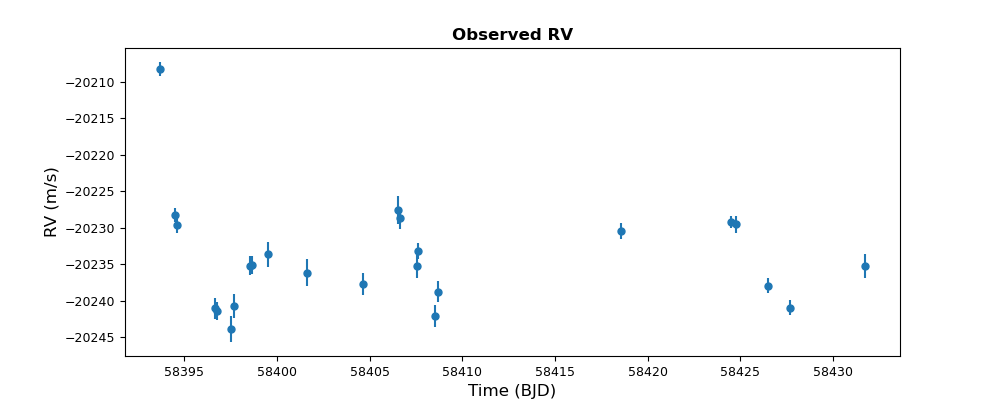

In [19]:
if RV == True:
    def plot_rv(rv_time, rv, rv_err):
        fig, ax = plt.subplots(figsize = (10,4))
        ax.errorbar(rv_time, rv, rv_err, fmt= 'o')
        ax.set_xlabel('Time (BJD)', fontsize = 12)
        ax.set_ylabel('RV (m/s)', fontsize = 12)
    
    def import_harps():
        try:
            rv_ts = Spectroscopy.get_timeseries(input_catalog, sorted_by_instrument = True)
        except:
            print('DACE import error: try again')
            
        index = []
        for each in rv_ts.keys():
            if each.find('HARPS15') != -1:
                index.append(each)
            elif each.find('HARPS') != -1:
                index.append(each)
        index0 = index[0]
        index1 = list(rv_ts[index0])[0]
        index2 = list(rv_ts[index0][index1])[0]
        rv_data = rv_ts[index0][index1][index2]
        rv_time, rv, rv_err = rv_data['rjd'], rv_data['rv'], rv_data['rv_err'] 
    
        if render_plots == True:
            plot_rv(rv_time, rv, rv_err)
            plt.title('Observed RV', fontsize = 12, fontweight = 'bold')
        
        rv_norm = (rv - np.median(rv))    
        sigma2 = 2*np.std(rv_norm)    
        
        i = 0 
        while i < len(rv_norm):
            if (rv_norm[i] > sigma2) or (rv_norm[i] < -sigma2):
                rv_time = np.delete(rv_time, i)
                rv = np.delete(rv, i)
                rv_err = np.delete(rv_err, i)
            i += 1
        return input_catalog, rv_time, rv, rv_err
    
    input_catalog, rv_time, rv, rv_err = import_harps()

parameter                     value      vary
per1                        6.03457      False
tc1                         3885.47       True
secosw1                           0      False
sesinw1                           0      False
logk1                       1.83608       True
gamma                      -20235.4      False
jit                     3.19656e-09       True
tp1                         3883.96           
e1                                0           
w1                                0           
k1                          6.27192           

Priors
------



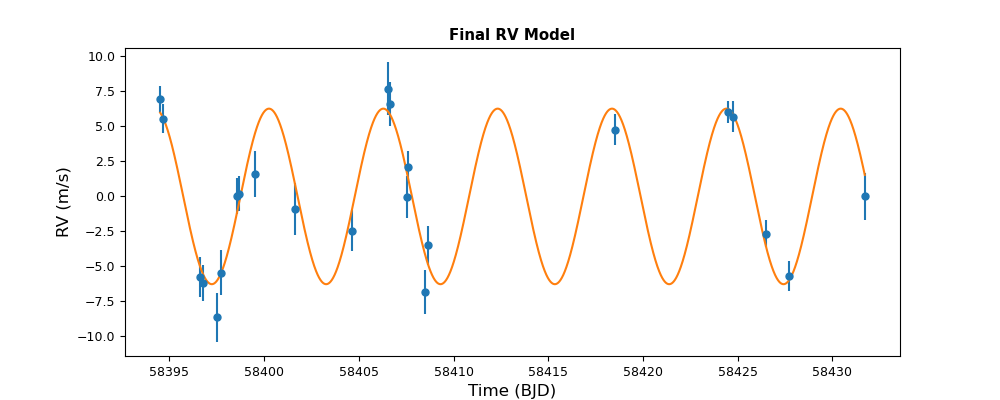

In [20]:
if RV == True:
    def initialize_model():
        time_base = int(np.mean(rv_time))
        params = radvel.Parameters(len(exoplanets), basis = 'per tc secosw sesinw logk')
        i = 0
        while i < len(exoplanets):
            params[f'per{i+1}'] = radvel.Parameter(value = exoplanets[i]['period'].value)
            params[f'tc{i+1}'] = radvel.Parameter(value = exoplanets[i]['transit_t0'].value)
            params[f'secosw{i+1}'] = radvel.Parameter(value = 0) 
            params[f'sesinw{i+1}'] = radvel.Parameter(value = 0)
            params[f'logk{i+1}'] = radvel.Parameter(value = np.log(np.std(rv)))
            i += 1
        radvel_model = radvel.RVModel(params, time_base = time_base)
        like = radvel.likelihood.RVLikelihood(radvel_model, rv_time, rv, rv_err)
        like.params['gamma'] = radvel.Parameter(value = np.median(rv), vary = False, linear = True)
        like.params['jit'] = radvel.Parameter(value = 1)
        i = 0
        while i < len(exoplanets):
            like.params[f'per{i+1}'].vary = False
            like.params[f'tc{i+1}'].vary = True
            like.params[f'secosw{i+1}'].vary = False
            like.params[f'sesinw{i+1}'].vary = False
            like.params[f'logk{i+1}'].vary = True
            i += 1
        #print(like)
        #plot_rv(rv_time, rv-np.median(rv), rv_err)
        #model_time = np.linspace(np.min(rv_time), np.max(rv_time), 10000)
        #plt.plot(model_time, like.model(model_time))
        #plt.title('Initial RV Model', fontweight = 'bold')
        return radvel_model, like

    def run_rvmodel():
        posterior = radvel.posterior.Posterior(like)
        results = optimize.minimize(posterior.neglogprob_array, posterior.get_vary_params(), method = 'Powell')
        derived_params = like.params.basis.to_synth(like.params)
        print(posterior)
        plot_rv(rv_time, rv-np.median(rv), rv_err)
        model_time = np.linspace(np.min(rv_time), np.max(rv_time), 10000)
        plt.plot(model_time, like.model(model_time))
        plt.title('Final RV Model', fontweight = 'bold')
        
    radvel_model, like = initialize_model()
    run_rvmodel()
    i = 0
    derived_params = like.params.basis.to_synth(like.params)
    while i < len(exoplanets):
        exoplanets[i]['semiamplitude']= derived_params[f'k{i+1}'].value*u.m/u.s
        i += 1

In [21]:
if RV == True:    
    def calc_mass(k, period, inclination):
        m1 = (period*u.day.to(u.s)*u.s)/(2*np.pi*const.G)
        m2 = k
        m3 = star['mass'][0]*u.M_sun.to(u.kg)*u.kg
        m4 = 1    #1-(eccentricity**2)
        d1 = np.sin(np.deg2rad(inclination))
        mass = ((m1**(1/3)) * m2 * (m3**(2/3)) * (m4**(1/2)))/d1
        mass_E = mass.to(u.Mearth)
        mass_J = mass.to(u.Mjupiter)
    
        if mass_E < 2*u.Mearth:
            exo_class = 'Terrestrial'
        elif mass_E < 10*u.Mearth:
            exo_class = 'Super-Earth'
        elif mass_E < 15*u.Mearth:
            exo_class = 'Sub-Neptune'
        elif mass_E < 150*u.Mearth:
            exo_class = 'Neptunian'
        elif mass_J < 13*u.Mjupiter:
            exo_class = 'Jovian'
        else:
            exo_class = 'Brown Dwarf'
        
        print(f'Mass: {round(mass_E, 4)}')
        print(f'Mass: {round(mass_J, 4)}')
        print(f'Class: {exo_class}')
        return mass_E, mass_J, exo_class
    
    for each in exoplanets:
        print(f'Exoplanet Index: {exoplanets.index(each)}')
        mass_E, mass_J, exo_class = calc_mass(each['semiamplitude'], each['period'].value, each['inclination'].value)
        each['mass_E'], each['mass_J'], each['exo_class'] = mass_E, mass_J, exo_class
        print()

Exoplanet Index: 0
Mass: 17.534 earthMass
Mass: 0.0552 jupiterMass
Class: Neptunian



In [22]:
if RV == True:
    def calc_bulk_density(mass, radius):
        volume = (4/3)*np.pi*((radius.to(u.cm))**3)
        mass_g = mass.to(u.g)
        bulk_density = mass_g/volume
        if bulk_density.value < 3:    
            composition = 'Ice/Gas' 
        elif bulk_density.value < 20:    
            composition = 'Iron/Rock'
        else:   
            composition = 'Degenerate'
            
        print(f'Bulk Density: {round(bulk_density, 4)}')
        print(f'Composition: {composition}')
        return bulk_density, composition
    
    def calc_surf_grav(mass, radius):
        mass_kg = mass.to(u.kg)
        radius_m = radius.to(u.m)
        surf_grav = (const.G*mass_kg)/(radius_m**2)
        print(f'Surface Gravity: {round(surf_grav, 4)}')
        return surf_grav
    
    for each in exoplanets:
        print(f'Exoplanet Index: {exoplanets.index(each)}')
        bulk_density, composition = calc_bulk_density(each['mass_E'], each['radius'])
        each['bulk_density'] = bulk_density
        each['composition'] = composition
        
        surf_grav = calc_surf_grav(each['mass_E'], each['radius'])
        each['surf_grav'] = surf_grav
        print()

Exoplanet Index: 0
Bulk Density: 1.1139 g / cm3
Composition: Ice/Gas
Surface Gravity: 8.7843 m / s2



### Results & Comparison

In [23]:
for exoplanet in exoplanets:
    match = nasa_exo[round(nasa_exo['pl_orbper']) == round(exoplanet['period'])]
    radius_accuracy = round((1-np.abs(match['pl_rade']-exoplanet['radius'])/match['pl_rade'])*100, 2)
    exoplanet['rad_acc'] = str(f'{radius_accuracy.iloc[0]}%')
    mass_accuracy = round((1-np.abs(match['pl_bmasse']-exoplanet['mass_E'])/match['pl_bmasse'])*100, 2)
    exoplanet['mass_acc'] = str(f'{mass_accuracy.iloc[0]}%')
    for each in exoplanet:
        try:
            if type(exoplanet[each]) != str:
                exoplanet[each] = round(exoplanet[each], 2)
        except:
            exoplanet[each] = round(float(exoplanet[each].value), 2)

pd.DataFrame(exoplanets).transpose()

,0
stellar_class,G-Type Yellow Dwarf
period,6.03 d
duration,0.07 d
transit_t0,3887.81
depth,1.47 mmag
snr,20.27
sm_axis,0.06 AU
equ_temp,1078.58 k
habitability,too hot
radius,4.42 earthRad


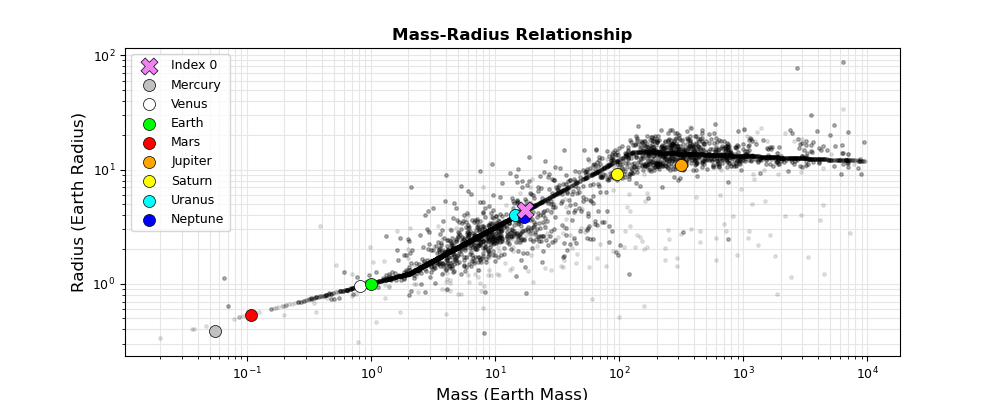

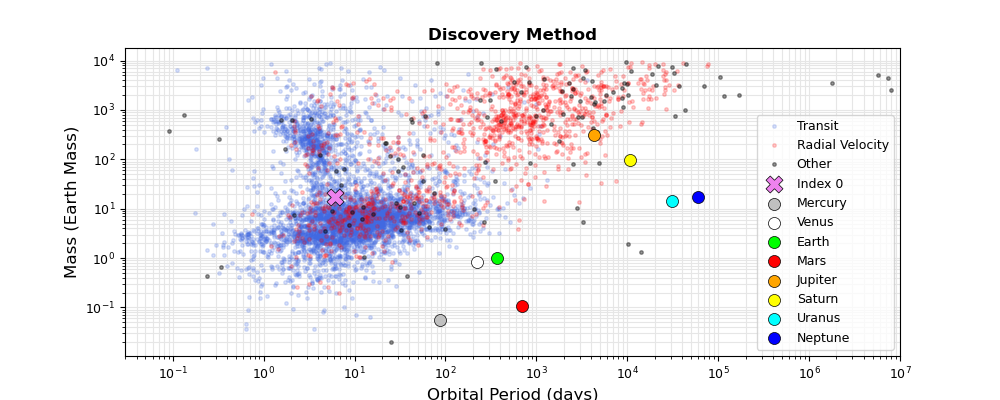

In [99]:
if RV == True and render_plots == True:
    def plot_mass_rad(exoplanet):
        fig, ax = plt.subplots(figsize = (10, 4))
        refined_constraints = np.logical_and(
            (nasa_archive['pl_radeerr1']/nasa_archive['pl_rade']) < 1,
            (nasa_archive['pl_bmasseerr1']/nasa_archive['pl_bmasse']) < 1
        )
        refined_archive = nasa_archive[refined_constraints]
        ax.loglog(nasa_archive['pl_bmasse'], nasa_archive['pl_rade'], '.', color = 'black', alpha = .1, zorder = 2)
        ax.loglog(refined_archive['pl_bmasse'], refined_archive['pl_rade'], '.', color = 'black', alpha = .2, zorder = 2)
        
        ax.grid(which = 'major', color = '.9', zorder = 1)
        ax.grid(which = 'minor', color = '.9', zorder = 1)
        ax.set_xlabel('Mass (Earth Mass)', fontsize = 12)
        ax.set_ylabel('Radius (Earth Radius)', fontsize = 12)
        ax.set_title('Mass-Radius Relationship', fontsize = 12, fontweight = 'bold')

        for each in exoplanets:
            if exoplanets.index(each) == 0:
                color = 'violet'
            if exoplanets.index(each) == 1:
                color = 'deepskyblue'
            if exoplanets.index(each) == 2:
                color = 'green'
            if exoplanets.index(each) == 3:
                color = 'gold'
            if exoplanets.index(each) == 4:
                color = 'salmon'
            
            ax.scatter(
                each['mass_E'].value, 
                each['radius'].value, 
                s = 150, 
                color = color, 
                marker = 'X', 
                edgecolor = 'black', 
                linewidth = .5, 
                label = (f'Index {exoplanets.index(each)}'), 
                zorder = 4
            )
        
        ax.scatter(0.0553, 0.383, s = 300, marker = '.', color = 'silver', label = 'Mercury', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(0.815, 0.95, s = 300, marker = '.', color = 'white', label = 'Venus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(1, 1, s = 300, marker = '.', color = 'lime', label = 'Earth', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(0.107, 0.53, s = 300, marker = '.', color = 'red', label = 'Mars', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(317.8, 10.97, s = 300, marker = '.', color = 'orange', label = 'Jupiter', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(95.2, 9.14, s = 300, marker = '.', color = 'yellow', label = 'Saturn', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(14.5, 3.98, s = 300, marker = '.', color = 'cyan', label = 'Uranus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(17.1, 3.86, s = 300, marker = '.', color = 'blue', label = 'Neptune', edgecolor = 'black', linewidths = .5, zorder = 3)
        plt.legend()

    def plot_per_mass(exoplanet):
        fig, ax = plt.subplots(figsize = (10, 4))

        disc_tran = nasa_archive[nasa_archive['discoverymethod'] == 'Transit']
        ax.loglog(disc_tran['pl_orbper'], disc_tran['pl_bmasse'], '.', color = 'royalblue', alpha = .2, label = 'Transit', zorder = 2)
        disc_rv = nasa_archive[nasa_archive['discoverymethod'] == 'Radial Velocity']
        ax.loglog(disc_rv['pl_orbper'], disc_rv['pl_bmasse'], '.', color = 'red', alpha = .2, label = 'Radial Velocity', zorder = 2)
        disc_other = nasa_archive[np.logical_and(nasa_archive['discoverymethod'] != 'Transit', nasa_archive['discoverymethod'] != 'Radial Velocity')]
        ax.loglog(disc_other['pl_orbper'], disc_other['pl_bmasse'], '.', color = 'black', label = 'Other', alpha = .4, zorder = 2)
        
        ax.grid(which = 'major', color = '.9', zorder = 1)
        ax.grid(which = 'minor', color = '.9', zorder = 1)
        ax.set_xlabel('Orbital Period (days)', fontsize = 12)
        ax.set_ylabel('Mass (Earth Mass)', fontsize = 12)
        ax.set_title('Discovery Method', fontsize = 12, fontweight = 'bold')
        plt.xlim(right = 10**7)

        for each in exoplanets:
            if exoplanets.index(each) == 0:
                color = 'violet'
            if exoplanets.index(each) == 1:
                color = 'deepskyblue'
            if exoplanets.index(each) == 2:
                color = 'green'
            if exoplanets.index(each) == 3:
                color = 'gold'
            if exoplanets.index(each) == 4:
                color = 'salmon'
            
            ax.scatter(
                each['period'].value, 
                each['mass_E'].value, 
                s = 150, 
                color = color, 
                marker = 'X', 
                edgecolor = 'black', 
                linewidth = .5, 
                label = (f'Index {exoplanets.index(each)}'), 
                zorder = 4
            )
        
        ax.scatter(87.97, 0.0553, s = 300, marker = '.', color = 'silver', label = 'Mercury', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(224.70, 0.815, s = 300, marker = '.', color = 'white', label = 'Venus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(365.26, 1, s = 300, marker = '.', color = 'lime', label = 'Earth', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(686.98, 0.107, s = 300, marker = '.', color = 'red', label = 'Mars', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(4332.82, 317.8, s = 300, marker = '.', color = 'orange', label = 'Jupiter', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(10755.70, 95.2, s = 300, marker = '.', color = 'yellow', label = 'Saturn', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(30687.15, 14.5, s = 300, marker = '.', color = 'cyan', label = 'Uranus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(60190.03, 17.1, s = 300, marker = '.', color = 'blue', label = 'Neptune', edgecolor = 'black', linewidths = .5, zorder = 3)
        plt.legend()

    plot_mass_rad(exoplanets)
    plot_per_mass(exoplanets)

#### Ideas for improvement
- merge transit & rv model
- add uncertainty margins (markov chain monte carlo)
- test loop comparing accuracy
- output results to external storage/spreadsheet
- import archive API instead of downloaded file
- test false positives
- imporove detection for longer periods
- transit timing variations
- atmospheric spectroscopy
- demonstrate doppler shift
- astrometry method